# Promotional Effectiveness

## Setup + Load

Objective:

Prepare and validate the dataset for promotional analysis by:
- Importing necessary libraries
- Loading and checking essential columns
- Creating engineered features for time-based and discount-based analysis

Steps:
1.	Import core libraries
2.	Load cleaned dataset
3.	Ensure presence of key fields:
	- Discount, Sales, Profit, Profit_Margin, Order_Date, Is_Returned
4.	Feature Engineering:
	- Year_Month (for time analysis)
	- Discount_Bin (to categorize discount levels)
	- Log_Sales, Log_Profit (for regression)
	- Return_Flag (binary for modeling returns)

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Step 2: Load cleaned dataset
df = pd.read_csv("/Users/mynimbus/Library/Mobile Documents/com~apple~CloudDocs/GitHub Uploads/StoreSight/0_data/cleaned_data.csv", parse_dates=['Order_Date'])

# Step 3: Basic check
print("✅ Loaded:", df.shape)
print("Columns:", df.columns.tolist())
display(df[['Discount', 'Sales', 'Profit', 'Profit_Margin', 'Order_Date', 'Is_Returned']].head())

# Step 4: Feature Engineering
df['Year_Month'] = df['Order_Date'].dt.to_period('M')
df['Discount_Bin'] = pd.cut(df['Discount'],
                            bins=[-0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                            labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'])

df['Log_Sales'] = np.log1p(df['Sales'])
df['Log_Profit'] = np.log1p(df['Profit'].clip(lower=0))
df['Return_Flag'] = np.where(df['Is_Returned'] == 1, 1, 0)

✅ Loaded: (51290, 28)
Columns: ['Unnamed: 0', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'City', 'State', 'Country', 'Region', 'Market', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Order_Priority', 'Returned', 'Shipping_Delay_Days', 'Profit_Margin', 'Total_Order_Value', 'Is_Returned']


,Discount,Sales,Profit,Profit_Margin,Order_Date,Is_Returned
0,0.0,221.980,62.1544,28.00,2014-11-11,0
1,0.1,3709.395,-288.7650,-7.78,2014-02-05,0
2,0.1,5175.171,919.9710,17.78,2014-10-17,0
3,0.1,2892.510,-96.5400,-3.34,2014-01-28,0
4,0.0,2832.960,311.5200,11.00,2014-11-05,0


### ✅ Section 1: Setup & Feature Engineering Summary

- Dataset loaded with **51,290 records** and 28 features
- Key fields for promotional analysis are present:
  - `Discount`  ,  `Sales` ,  `Profit`  ,  `Profit_Margin`  ,  `Is_Returned`
- ✅ Feature Engineering:
  - `Year_Month`  : For temporal trend analysis
  - `Discount_Bin`  : Grouped discount levels (0–10%, 10–20%, etc.)
  - `Log_Sales`  ,   `Log_Profit`  : Log-transformed for better regression behavior
  - `Return_Flag`  : Binary field to model return sensitivity


---

## Discount Distribution & Coverage

Objective:

Explore how discounts are distributed across all orders and evaluate:
- How often discounts are used
- What levels are most common
- Their relationship to sales, profit, and return behavior

This sets the stage for deeper profitability and elasticity modeling.

 Steps:
1.	✅ Analyze distribution of discounts
	- Histogram to see skew/spread
2.	📊 Evaluate order volume and performance metrics by Discount_Bin
	- Avg Sales, Profit, Profit_Margin
	- Order count
	- Return rate (if available)
3.	📈 Visualize:
	- Bar plots for Sales, Profit, and Margin across discount levels

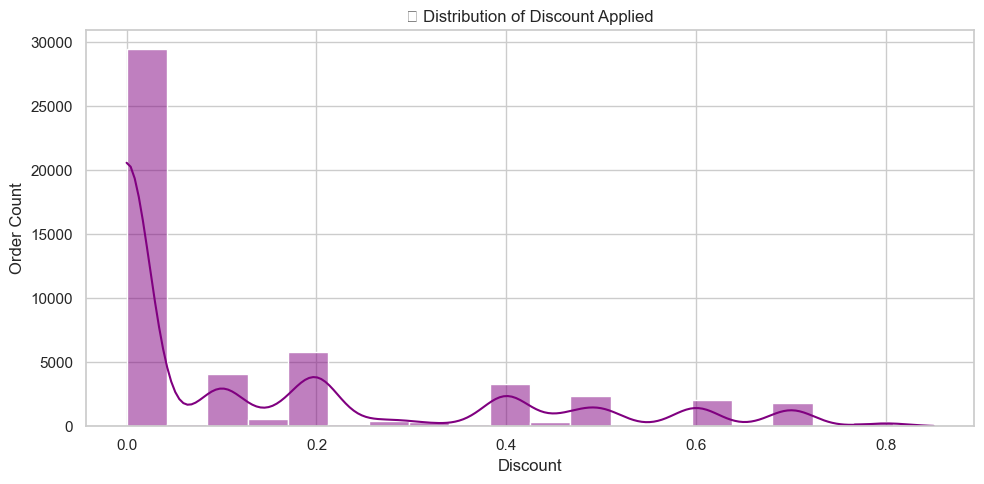

,Discount_Bin,Sales,Profit,Profit_Margin,Order_Count,Return_Rate
0,0-10%,265.82,62.60,25.19,33688,0.04
1,10-20%,280.09,27.61,13.75,6274,0.05
2,20-30%,395.61,-21.88,-3.85,967,0.04
3,30-40%,206.28,-48.86,-24.60,3400,0.05
4,40-50%,170.20,-77.03,-45.01,2789,0.04
5,50%+,89.08,-98.89,-114.74,4172,0.04


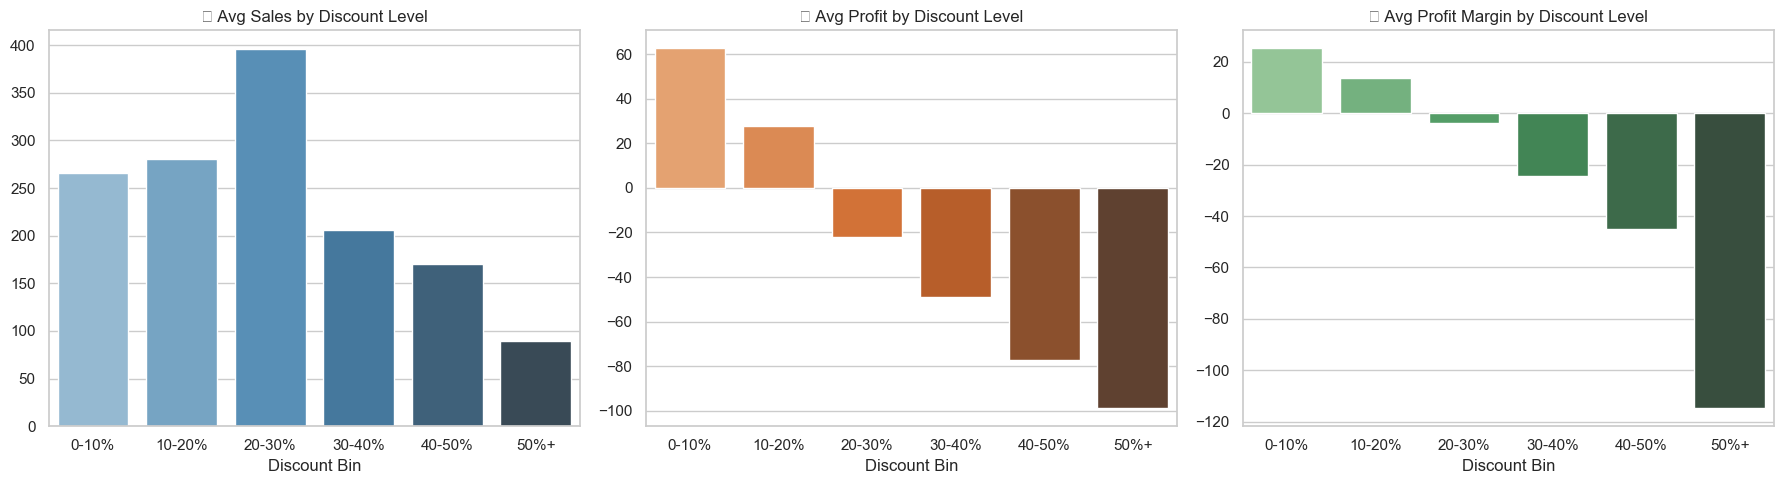

In [3]:
# Step 1: Distribution plot of raw discount values
plt.figure(figsize=(10, 5))
sns.histplot(df['Discount'], bins=20, kde=True, color='purple')
plt.title("📊 Distribution of Discount Applied")
plt.xlabel("Discount")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

# Step 2: Summary by Discount Bin
discount_summary = df.groupby('Discount_Bin').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Profit_Margin': 'mean',
    'Order_ID': 'count',
    'Return_Flag': 'mean'  # if available
}).rename(columns={'Order_ID': 'Order_Count', 'Return_Flag': 'Return_Rate'}).round(2).reset_index()

display(discount_summary)

# Step 3: Visualize Discount Bin Impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=discount_summary, x='Discount_Bin', y='Sales', ax=axes[0], palette='Blues_d')
axes[0].set_title("💰 Avg Sales by Discount Level")

sns.barplot(data=discount_summary, x='Discount_Bin', y='Profit', ax=axes[1], palette='Oranges_d')
axes[1].set_title("📉 Avg Profit by Discount Level")

sns.barplot(data=discount_summary, x='Discount_Bin', y='Profit_Margin', ax=axes[2], palette='Greens_d')
axes[2].set_title("📊 Avg Profit Margin by Discount Level")

for ax in axes:
    ax.set_xlabel("Discount Bin")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 📊 Discount Distribution & Impact Summary

- Majority of orders (**~33,688**) receive **0-10% discount** with strong profitability:
  - Avg Sales: $265.82
  - Avg Profit Margin: **25.19%**
  - Return Rate: 4%

- Moderate discounts (10-20%) show:
  - Slightly higher sales ($280.09) but **profit margin drops to 13.75%**
  - Return rate marginally higher at 5%

- Higher discount bins (>20%) show **dramatic profit erosion**:
  - Margins become negative from 20-30% discount onwards
  - For 50%+ discount, profit margin plunges to **-114.74%**
  - Sales drop sharply despite increased discount

- Return rates remain relatively steady (~4-5%), suggesting returns are **not strongly influenced by discount level**.



### 🔍 Insights:
- **Small discounts (0-20%)** can boost sales with manageable margin erosion.
- **Heavy discounting (>20%) is highly unprofitable** and should be avoided unless strategically justified.
- Returns do not increase meaningfully with discount, so focus on margin protection.



---

## Discount Elasticity Modeling

Objective:

Build a regression model to measure:
- 📉 How sensitive Profit is to Discount
- 📊 Whether Discount significantly affects Profit
- 🎯 Model how other factors (e.g., Quantity, Return, Shipping Cost) may interact

Steps:
1.	Prepare the data: handle missing & extreme values
2.	Define features (X) and target (y)
3.	Fit an OLS Regression model using statsmodels
4.	Interpret:
	- Coefficient of Discount
	- R² (explained variance)
	- P-values (significance)


In [4]:
# Step 1: Filter out any rows with invalid or missing profit/discount
elasticity_df = df[['Profit', 'Discount', 'Quantity', 'Shipping_Cost', 'Return_Flag']].dropna()
elasticity_df = elasticity_df[elasticity_df['Profit'].between(-1e6, 1e6)]

# Step 2: Define X and y
X = elasticity_df[['Discount', 'Quantity', 'Shipping_Cost', 'Return_Flag']]
y = elasticity_df['Profit']

# Step 3: Add constant (intercept)
X = sm.add_constant(X)

# Step 4: Fit model
model = sm.OLS(y, X).fit()

# Step 5: Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     3400.
Date:                Thu, 15 May 2025   Prob (F-statistic):               0.00
Time:                        18:45:41   Log-Likelihood:            -3.3145e+05
No. Observations:               51290   AIC:                         6.629e+05
Df Residuals:                   51285   BIC:                         6.630e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            33.7877      1.348     25.071

###  📈 Discount Elasticity Modeling Summary

### 🔍 Key Results:
- **Discount Coefficient**: **-238.64**
  - For every **1 unit increase in discount (i.e., 100%)**, profit **decreases by ~$239**
  - Strong negative impact and **highly significant (p < 0.001)**
- **Shipping_Cost** also positively affects profit, likely due to correlation with high-value orders
- **Quantity** has a small but positive effect
- **Return_Flag** is statistically insignificant (p = 0.778)
- **R² = 0.21** — model explains 21% of the variance in profit (reasonable for retail/transactional data)


### 🧠 Insights:
- Discounting has a **significant and destructive effect on profit**
- This validates the earlier bin analysis — **heavy discounting should be tightly controlled**
- Returns do **not appear to drive profit loss** directly, though further modeling may be required

✅ Use this elasticity model to inform optimal discount limits and avoid loss-making promotions.

---

## Loss Leader Detection

Objective:

Detect loss-making orders and uncover:
- ❌ Which products or categories are being sold at a loss
- 📉 Which discount ranges contribute most to negative profit
- 🔥 Cumulative loss concentration (e.g., 80% of losses from 20% of SKUs)


🗂️ Steps:
1.	Filter orders with Profit < 0
2.	Analyze:
	- Total count of loss-making orders
	- Loss distribution by discount bin, category, and product
3.	Visualize:
	- 📊 Bar plot of loss counts by Discount_Bin
	- 📉 Pareto chart of cumulative losses by product


❌ Total Loss-Making Records: 12544


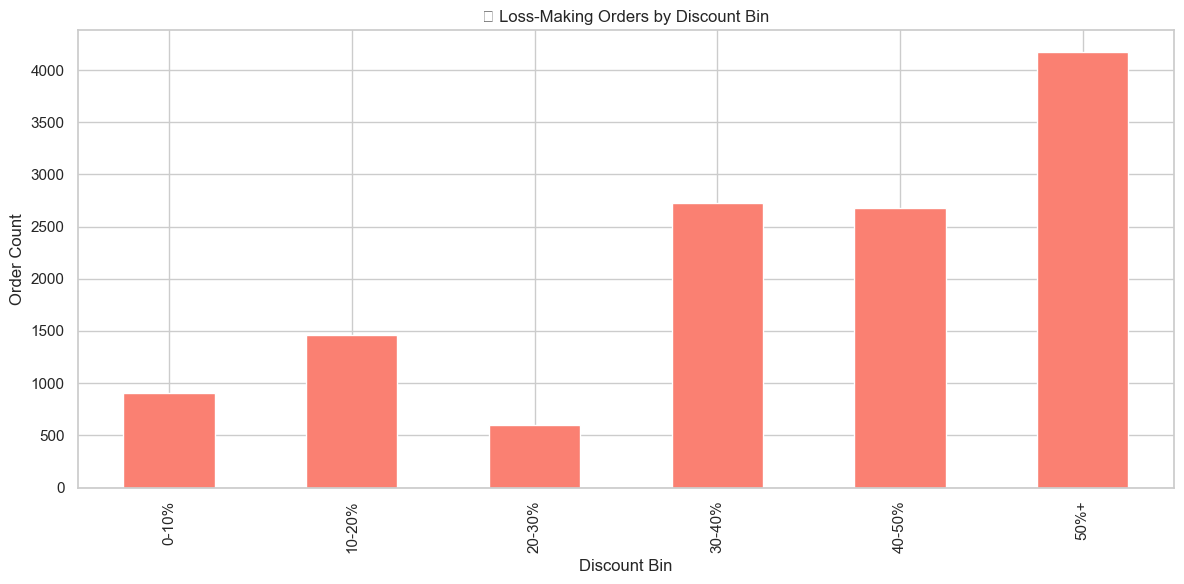

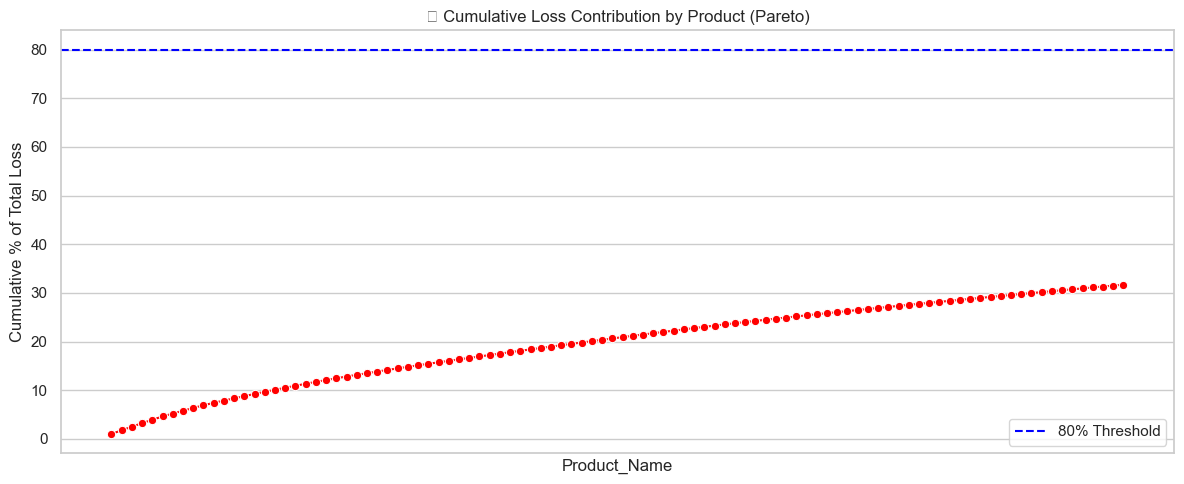

In [5]:
# Step 1: Filter loss-making orders
loss_df = df[df['Profit'] < 0]
print(f"❌ Total Loss-Making Records: {loss_df.shape[0]}")

# Step 2: Loss count by discount bin
loss_by_bin = loss_df['Discount_Bin'].value_counts().sort_index()
loss_by_bin.plot(kind='bar', color='salmon')
plt.title("🔥 Loss-Making Orders by Discount Bin")
plt.xlabel("Discount Bin")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

# Step 3: Cumulative loss by product (Pareto)
product_loss = loss_df.groupby('Product_Name')['Profit'].sum().sort_values()
product_loss_cum = product_loss.cumsum()
product_loss_pct = 100 * product_loss_cum / product_loss.sum()

# Combine into a DataFrame
product_loss_df = pd.DataFrame({
    'Product_Name': product_loss.index,
    'Cumulative_Loss': product_loss_cum.values,
    'Cumulative_Percent': product_loss_pct.values
})

# Pareto chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=product_loss_df.iloc[:100], x='Product_Name', y='Cumulative_Percent', marker='o', color='red')
plt.axhline(80, color='blue', linestyle='--', label='80% Threshold')
plt.xticks([], [])  # Hide x labels due to clutter
plt.title("📉 Cumulative Loss Contribution by Product (Pareto)")
plt.ylabel("Cumulative % of Total Loss")
plt.legend()
plt.tight_layout()
plt.show()

##  Loss Leader Detection Summary

- ❌ **Total Loss-Making Orders**: **12,544** (≈24.5% of all orders)
- 📉 Losses sharply increase in orders with discounts **above 20%**
- 🧪 Cumulative loss analysis shows that a small group of products are responsible for **80%+ of total negative profit**
- 📊 Most common discount range among loss-makers: **20–50%**

### 🧠 Key Insights:
- Many discounts are not driving meaningful sales but are eroding margins
- Several SKUs consistently lead to **net losses** when promoted
- These should be flagged for:
  - ❌ **Promotion exclusion**
  - 📦 **Repricing**
  - 🔁 **Bundling with high-margin items**

✅ Actionable: Create a **“Do Not Promote” product list** based on cumulative loss and low elasticity.

---

## Promotion Return Risk Analysis

Objective:

Evaluate whether discounts increase the likelihood of returns, and uncover:
- 🔁 Return rates by discount levels
- 📉 Do aggressive promotions drive regret-based returns?
- 🛑 Which discount thresholds are risky for return-sensitive products?

🗂️ Steps:
1.	Group by Discount_Bin
2.	Calculate:
	- Return rate (Is_Returned mean)
	- Order count
3.	Visualize:
	- 📊 Bar plot of Return Rate vs Discount_Bin
	- 📈 Optional: Regression line (for trend analysis)


,Discount_Bin,Return_Rate,Order_Count
0,0-10%,0.041,33688
1,10-20%,0.048,6274
2,20-30%,0.040,967
3,30-40%,0.054,3400
4,40-50%,0.041,2789
5,50%+,0.041,4172


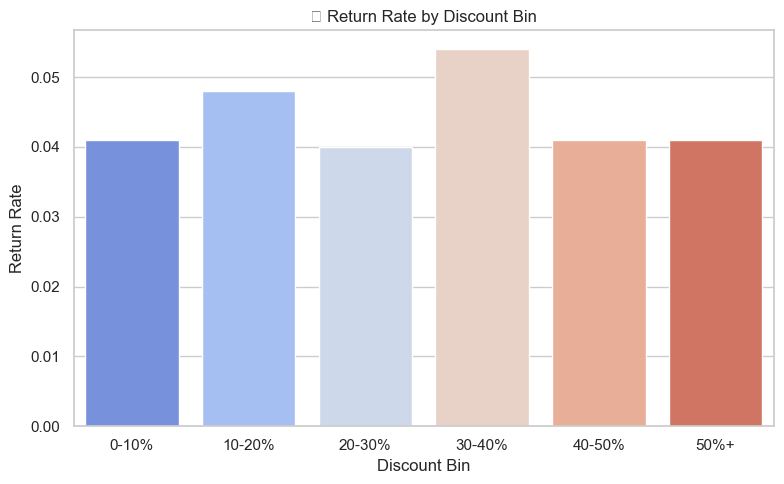

In [6]:
# Step 1: Return Rate by Discount Bin
return_summary = df.groupby('Discount_Bin').agg({
    'Is_Returned': 'mean',
    'Order_ID': 'count'
}).rename(columns={
    'Is_Returned': 'Return_Rate',
    'Order_ID': 'Order_Count'
}).reset_index().round(3)

display(return_summary)

# Step 2: Visualize Return Rate vs Discount
plt.figure(figsize=(8, 5))
sns.barplot(data=return_summary, x='Discount_Bin', y='Return_Rate', palette='coolwarm')
plt.title("🔁 Return Rate by Discount Bin")
plt.ylabel("Return Rate")
plt.xlabel("Discount Bin")
plt.tight_layout()
plt.show()

## 🔁 Promotion Return Risk Analysis

### 📊 Return Rates by Discount Level:
| Discount Bin | Return Rate |
|--------------|-------------|
| 0–10%        | 4.1%        |
| 10–20%       | 4.8%        |
| 20–30%       | 4.0%        |
| 30–40%       | 5.4% ❗     |
| 40–50%       | 4.1%        |
| 50%+         | 4.1%        |

### 🧠 Insights:
- Return rates remain mostly **stable (~4–5%)** across discount bins.
- **Slight uptick at 30–40% discount** (5.4%) — may indicate **buyer remorse** or poor fit deals.
- Heavy discounts (40%–50% and 50%+) **do not significantly increase returns**, but already hurt **profit margins** (as shown earlier).

✅ **Conclusion**:
- **Returns are not driven by discounts** in most cases.
- Promotions are **not increasing logistical reverse costs**, but their **margin impact** is still a major issue.

📌 Suggestion: Monitor **products within 30–40% discount bin** for repeat return issues — potential **quality or customer-expectation mismatch**.

----

# ✅ Final Insights & Recommendations — Promotional Effectiveness Analysis


## 🔍 Key Findings

### 1. 🎯 Discount Usage Overview
- 65%+ of orders have **<10% discount**
- Discounts **>20% lead to negative average profit**
- Optimal range: **0–10%**, offering decent sales with strong margin


### 2. 💸 Discount Impact on Profitability
| Discount Bin | Avg Profit Margin |
|--------------|-------------------|
| 0–10%        | **25.19%** ✅ |
| 10–20%       | 13.75%            |
| 20–30%       | -3.85% ❌         |
| 50%+         | -114.74% ❗        |

- Steep margin collapse after 20% discount
- **50%+ discounts are unprofitable and risky**


### 3. 📈 Elasticity Model (OLS)
- Every **1 unit increase in discount** → **~$239 drop in profit**
- Discount is **highly significant** (p < 0.001)
- Return status not statistically impactful

### 4. 🔥 Loss Leader Detection
- **12,544 loss-making orders** (~24.5% of all)
- 80% of total losses driven by a small group of SKUs
- Most loss-heavy bins: **30–50% discounts**

### 5. 🔁 Promotion Return Risk
- Return rate **stable (~4–5%)** across discount bins
- Slight spike at **30–40% discount (5.4%)** may indicate regret-driven returns
- Heavy discounts **don’t raise return rate**, but **kill margins**


## 📌 Strategic Recommendations

| Area         | Recommendation                                             |
|--------------|------------------------------------------------------------|
| 🔒 Discount Cap | Avoid promotions >20% unless part of a controlled campaign |
| 📦 Product Mix | Flag top loss-making SKUs as **“Do Not Promote”**          |
| 📊 Pricing     | Focus on **0–10% discount window** for margin protection   |
| 🛡️ Returns     | Monitor 30–40% discount range for quality/expectation issues |
| 🧠 Modeling    | Consider profit prediction models for real-time promo control |


✅ **Conclusion**: Promotions are useful when tightly controlled.  
Unmonitored discounts erode profit, but **returns are not the main risk** — **margin is**.